# Seville CMIP6 SSP5-8.5 Projection EDA (2026-2045)

Applies the same processing and indicator-calculation pipeline used in `seville_era5_eda.ipynb` to
the CMIP6 `cmcc_esm2` SSP5-8.5 projection pulled by `pull_cmip6_projections.py`, wherever that
pipeline actually transfers to daily-native projection data. Sections that don't apply (6-hourly
resampling, wind-direction/rose, sub-daily heat index) are dropped rather than faked; sections that
would silently redefine a "fixed" threshold from the projection data itself (the P90 heatwave
threshold) instead load and reuse the threshold already fit on the ERA5 1990-2020 reference period,
per `fixed_reference_period_principle.md`.

**Source data:** `data/seville_cmip6_ssp585_2026_2045.csv` (model `cmcc_esm2`, experiment
`ssp5_8_5`, 4 grid points in the Seville bounding box, 2026-01-01 to 2045-12-31).

**Historical reference** (for fixed thresholds and the ERA5-vs-projection comparison):
`eda_results/eda_outputs/seville_daily.csv` and `annual_summary.csv`, from `seville_era5_eda.ipynb`.

**Known limitations, stated once here rather than repeated throughout:** raw (non-bias-corrected)
CMIP6 output at a single grid box, one model, one scenario -- see
`documentation/projection_data_pull_plan.md` Step 6 and `project_summary.md`'s "illustrative of
directional risk rather than definitive climate-model consensus" framing. Full breakdown of what
carries over vs. what doesn't is in Section 12 below.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)

RAW_CSV = Path("data/seville_cmip6_ssp585_2026_2045.csv")
ERA5_DAILY_CSV = Path("eda_results/eda_outputs/seville_daily.csv")
ERA5_ANNUAL_CSV = Path("eda_results/eda_outputs/annual_summary.csv")
OUT = Path("eda_results/eda_outputs_seville_projection")
OUT.mkdir(parents=True, exist_ok=True)

# Fixed reference period -- used only to fit thresholds below, never refit on new data.
# See fixed_reference_period_principle.md.
REFERENCE_START, REFERENCE_END = 1990, 2020

## 1. Load the raw CMIP6 pull

`pull_cmip6_projections.py` merges 7 separately-downloaded variables on `(valid_time, lat, lon)`,
but each variable also carries its own 2-valued `bnds` dimension (from `time_bnds`/`lat_bnds`/
`lon_bnds`) that isn't part of the merge key -- 6 successive merges of a 2-valued, unmerged
dimension multiply row count by 2**6 = 64. Every "duplicate" row is value-identical (confirmed by
`nunique()==1` per group before writing this notebook), so it doesn't bias any mean computed
downstream, but it inflates the frame ~64x for no reason and would make row-count sanity checks
misleading if left in. Dropped explicitly below, as a documented QC step.

In [2]:
raw = pd.read_csv(RAW_CSV, parse_dates=["valid_time"])
print(f"raw shape: {raw.shape}")
print(raw.columns.tolist())

BNDS_COLS = ["bnds", "time_bnds", "lat_bnds", "lon_bnds", "height"]
df = raw.drop(columns=[c for c in BNDS_COLS if c in raw.columns]).drop_duplicates().reset_index(drop=True)

n_days = df["valid_time"].nunique()
n_points = df[["lat", "lon"]].drop_duplicates().shape[0]
print(f"deduped shape: {df.shape}  (expected {n_days} days x {n_points} grid points = {n_days * n_points})")
assert df.shape[0] == n_days * n_points, "dedup did not fully resolve the bnds cross-join"
df.head()

raw shape: (3737600, 17)
['valid_time', 'bnds', 'lat', 'lon', 'time_bnds', 'lat_bnds', 'lon_bnds', 'tas', 'height', 'tasmax', 'tasmin', 'pr', 'huss', 'sfcWind', 'psl', 'precip_mm_day', 'relative_humidity_pct']


deduped shape: (29200, 12)  (expected 7300 days x 4 grid points = 29200)


,valid_time,lat,lon,tas,tasmax,tasmin,pr,huss,sfcWind,psl,precip_mm_day,relative_humidity_pct
0,2026-01-01,37.225131,353.75,288.03412,291.29816,285.83078,1.306086e-06,0.008294,1.879336,102753.700,0.112846,80.715540
1,2026-01-01,37.225131,355.00,286.91867,290.48430,284.60208,4.477200e-07,0.007775,1.689602,102821.720,0.038683,81.401140
2,2026-01-01,38.167539,353.75,286.11728,289.69455,283.57596,1.613395e-06,0.008075,1.324884,102784.200,0.139397,89.018105
3,2026-01-01,38.167539,355.00,285.58360,289.15518,282.59970,1.024803e-07,0.007589,1.204583,102849.266,0.008854,86.715810
4,2026-01-02,37.225131,353.75,287.52008,291.73572,284.50742,1.280851e-06,0.008072,2.897154,102269.280,0.110666,80.824820


## 2. Physical plausibility check

Same spirit as the ERA5 notebook's bounds check (its section 2), with CMIP6-appropriate ranges:
temperature is still in Kelvin, `pr` is a flux (kg/m2/s, tiny values), `psl` is in Pa, `huss` is
specific humidity (kg/kg, small), `sfcWind` is a scalar speed in m/s.

In [3]:
BOUNDS = {
    "tas": (250, 325), "tasmax": (250, 330), "tasmin": (245, 320),
    "pr": (0, 0.005),           # kg m-2 s-1 -- 0.005 corresponds to ~430 mm/day, a generous upper bound
    "huss": (0, 0.03),
    "sfcWind": (0, 40),
    "psl": (90000, 108000),
    "precip_mm_day": (0, 400),
    "relative_humidity_pct": (0, 100),
}
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        continue
    n_bad = (~df[col].between(lo, hi)).sum()
    print(f"{col:24s} range=({df[col].min():.4g}, {df[col].max():.4g})  out-of-bounds={n_bad}")

# precip_mm_day carries tiny floating-point negative noise (~-1e-4) from the flux conversion at
# near-zero rainfall -- clip rather than treat it as a QC failure.
df["precip_mm_day"] = df["precip_mm_day"].clip(lower=0)

tas                      range=(276.5, 313.8)  out-of-bounds=0
tasmax                   range=(279.4, 319.7)  out-of-bounds=0
tasmin                   range=(272.7, 308.5)  out-of-bounds=0
pr                       range=(-2.038e-19, 0.0006276)  out-of-bounds=44
huss                     range=(0.001658, 0.01824)  out-of-bounds=0
sfcWind                  range=(0.6473, 9.239)  out-of-bounds=0
psl                      range=(9.992e+04, 1.044e+05)  out-of-bounds=0
precip_mm_day            range=(-1.761e-14, 54.22)  out-of-bounds=44
relative_humidity_pct    range=(9.001, 100)  out-of-bounds=0


## 3. Unit conversions

Temperature: the same `- 273.15` Kelvin to Celsius conversion the ERA5 pipeline used. Precipitation,
specific humidity, wind speed, and relative humidity are already in their final units/derived form
(`pull_cmip6_projections.py` did the `pr x 86400` flux conversion and the specific-humidity to RH
Magnus-formula derivation upstream) -- nothing left to convert for those.

In [4]:
df["tas_c"] = df["tas"] - 273.15
df["tasmax_c"] = df["tasmax"] - 273.15
df["tasmin_c"] = df["tasmin"] - 273.15
df[["tas_c", "tasmax_c", "tasmin_c"]].describe()

,tas_c,tasmax_c,tasmin_c
count,29200.000000,29200.000000,29200.000000
mean,20.818082,25.356586,16.481169
std,8.154220,8.648257,7.505419
min,3.334400,6.298150,-0.404060
25%,13.522345,17.621683,9.930825
50%,20.001290,24.588970,15.720840
75%,28.013220,32.988260,22.980623
max,40.686000,46.535200,35.328450


## 4. Grid-point averaging (4 points to 1 daily series)

Same unweighted arithmetic mean the ERA5 pipeline used (no distance/area weighting there either).
Relative humidity is a nonlinear function of temperature, humidity, and pressure, so -- matching
the ERA5 notebook's own discipline of recomputing RH from averaged inputs rather than averaging RH
itself -- it's recomputed here from the grid-averaged `tas`/`huss`/`psl`, using the identical
Magnus-formula derivation `pull_cmip6_projections.py` used per grid point.

In [5]:
BASE = ["tas", "tasmax", "tasmin", "tas_c", "tasmax_c", "tasmin_c",
        "precip_mm_day", "sfcWind", "huss", "psl"]

sev = df.groupby("valid_time")[BASE].mean()

def derive_rh(tas_k, huss, psl_pa):
    """Identical formula to pull_cmip6_projections.py's per-grid-point derivation, applied here
    to the grid-averaged base variables instead -- mirrors the ERA5 notebook's rule of recomputing
    nonlinear quantities from averaged inputs, not averaging the nonlinear output directly."""
    t_c = tas_k - 273.15
    p_hpa = psl_pa / 100.0
    q = huss
    vapor_pressure = q * p_hpa / (0.622 + 0.378 * q)
    sat_vapor_pressure = 6.112 * np.exp(17.62 * t_c / (243.12 + t_c))
    return np.clip(100 * vapor_pressure / sat_vapor_pressure, 0, 100)

sev["relative_humidity_pct"] = derive_rh(sev["tas"], sev["huss"], sev["psl"])
sev.head()

,tas,tasmax,tasmin,tas_c,tasmax_c,tasmin_c,precip_mm_day,sfcWind,huss,psl,relative_humidity_pct
valid_time,,,,,,,,,,,
2026-01-01,286.663417,290.158048,284.152130,13.513418,17.008048,11.002130,0.074945,1.524601,0.007933,102802.22150,84.421063
2026-01-02,286.222168,290.413757,283.296740,13.072168,17.263758,10.146740,0.096145,2.830201,0.007599,102372.60250,82.895557
2026-01-03,286.875077,292.167925,283.682037,13.725078,19.017925,10.532038,0.071974,1.537889,0.007280,102412.93025,76.147755
2026-01-04,286.315275,290.876410,283.052990,13.165275,17.726410,9.902990,0.120777,2.455635,0.006723,102747.02500,73.195486
2026-01-05,285.727307,289.661513,283.144360,12.577308,16.511513,9.994360,0.073602,2.850088,0.006654,102584.86275,75.166192


## 5. Daily frame

CMIP6's `projections-cmip6` dataset already provides true daily `tasmax`/`tasmin`, not an
approximation from sparse sub-daily samples -- so unlike the ERA5 pipeline (which resampled
6-hourly data with `.resample("D").max()/.min()/.sum()`), there's no resampling step here at all;
`sev` (indexed by `valid_time`, already one row per day) *is* the daily frame. Columns are renamed
to match the ERA5 notebook's naming convention so the indicator-calculation code below is close to
a direct port.

One genuine definitional gap: `heat_index_c` here is computed once per day from the single daily
mean temperature/RH CMIP6 provides, not (as in the ERA5 pipeline) the max of six intra-day
heat-index samples -- there's no sub-daily data to take a max over. It is **not** the same quantity
as the historical `heat_index_max_c` and is named differently here to avoid implying otherwise.

In [6]:
def compute_heat_index(t_c, rh):
    """Identical NWS Rothfusz fit used in the ERA5 notebooks (degF internally, converted back to degC)."""
    t_f = t_c * 9 / 5 + 32
    simple = 0.5 * (t_f + 61.0 + (t_f - 68.0) * 1.2 + rh * 0.094)
    hi_f = (-42.379 + 2.04901523 * t_f + 10.14333127 * rh - 0.22475541 * t_f * rh - 6.83783e-3 * t_f**2
            - 5.481717e-2 * rh**2 + 1.22874e-3 * t_f**2 * rh + 8.5282e-4 * t_f * rh**2 - 1.99e-6 * t_f**2 * rh**2)
    return (np.where(t_f < 80, simple, hi_f) - 32) * 5 / 9

daily = pd.DataFrame({
    "tmax_c": sev["tasmax_c"],
    "tmin_c": sev["tasmin_c"],
    "tmean_c": sev["tas_c"],
    "precip_mm_day": sev["precip_mm_day"],
    "wind_avg": sev["sfcWind"],
    "rh_mean_percent": sev["relative_humidity_pct"],
})
daily["dtr_c"] = daily["tmax_c"] - daily["tmin_c"]
daily["heat_index_c"] = compute_heat_index(daily["tmean_c"], daily["rh_mean_percent"])
daily["year"] = daily.index.year
daily["month"] = daily.index.month

daily.to_csv(OUT / "seville_projection_daily.csv")
daily.describe()

,tmax_c,tmin_c,tmean_c,precip_mm_day,wind_avg,rh_mean_percent,dtr_c,heat_index_c,year,month
count,7300.000000,7300.000000,7300.000000,7.300000e+03,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,25.356586,16.481169,20.818082,6.798493e-01,2.584132,51.388516,8.875417,19.999490,2035.500000,6.526027
std,8.592796,7.444726,8.108147,2.349795e+00,0.859514,21.113973,2.413172,8.055656,5.766676,3.448088
min,7.335250,0.779128,4.512483,0.000000e+00,0.771646,11.138032,1.086467,2.202162,2026.000000,1.000000
25%,17.594731,9.912374,13.469923,1.261216e-09,1.923196,32.612097,7.267829,12.712191,2030.750000,4.000000
50%,24.626371,15.731883,19.959021,3.912565e-03,2.488041,49.616848,8.994070,19.334878,2035.500000,7.000000
75%,32.956796,23.045046,28.016579,1.657848e-01,3.124460,70.325779,10.535733,27.333627,2040.250000,10.000000
max,46.065995,34.211470,39.935970,4.457985e+01,7.187507,99.763938,17.458957,38.339526,2045.000000,12.000000


## 6. Fixed reference-period thresholds (loaded from ERA5, 1990-2020, never refit here)

The ERA5 notebook's percentile-based heatwave detection computes a calendar-day P90 threshold
(`tmax_c`, +/-7-day window, pooled across years) inline from whatever `daily` frame is in scope. If
that code were copy-pasted unmodified into this notebook, `daily` would be the *projection* frame,
and the P90 baseline would be silently redefined from 2026-2045 data -- exactly the shifting-baseline
failure `fixed_reference_period_principle.md` warns against, and precisely backwards for a
comparison whose entire point is "how do projected hot days compare to the historical normal." The
threshold is instead computed once here from the ERA5 historical daily series, restricted to the
documented 1990-2020 reference period (the ERA5 notebook itself pooled its full 1990-2025 record
when computing this threshold inline -- a minor inconsistency with the documented principle, not
repeated here).

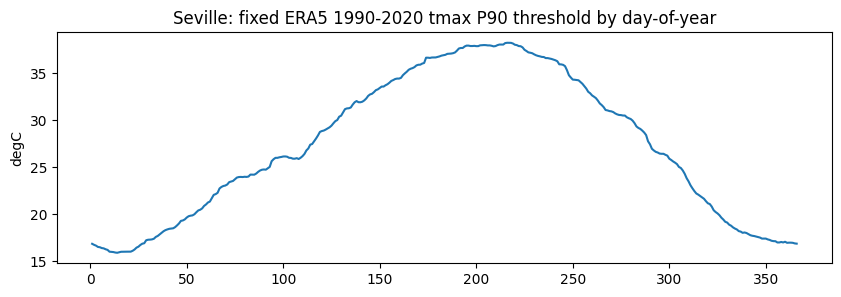

In [7]:
era5_daily = pd.read_csv(ERA5_DAILY_CSV, parse_dates=["valid_time"])
era5_daily["year"] = era5_daily["valid_time"].dt.year
ref = era5_daily[era5_daily["year"].between(REFERENCE_START, REFERENCE_END)].copy()
ref["doy"] = ref["valid_time"].dt.dayofyear

tmax_p90_by_doy = {}
for doy in range(1, 367):
    window = [((doy - 1 + k) % 366) + 1 for k in range(-7, 8)]
    tmax_p90_by_doy[doy] = ref.loc[ref["doy"].isin(window), "tmax_c"].quantile(0.90)

pd.Series(tmax_p90_by_doy).plot(
    title="Seville: fixed ERA5 1990-2020 tmax P90 threshold by day-of-year", figsize=(10, 3))
plt.ylabel("degC")
plt.show()

## 7. Indicator calculation

Hot-day threshold counts and the tropical-night threshold are fixed absolute values in the ERA5
notebook (not fit from data), so they carry over unchanged. Heatwaves apply the fixed P90-by-doy
dict from Section 6 to the *projection's* `tmax_c`, with the same >=3-consecutive-day run
requirement.

In [8]:
THRESH = [30, 33, 35, 37, 40]

d = daily.copy()
d["doy"] = d.index.dayofyear
d["tmax_p90"] = d["doy"].map(tmax_p90_by_doy)
d["exceed"] = d["tmax_c"] > d["tmax_p90"]

grp = (d["exceed"] != d["exceed"].shift()).cumsum()
runs = (d[d["exceed"]]
        .groupby(grp[d["exceed"]])
        .agg(start=("tmax_c", lambda s: s.index.min()),
             length=("tmax_c", "size"),
             peak=("tmax_c", "max"),
             mean_tmax=("tmax_c", "mean")))
heatwaves = runs[runs["length"] >= 3].reset_index(drop=True)
heatwaves["year"] = pd.to_datetime(heatwaves["start"]).dt.year
heatwaves.to_csv(OUT / "seville_projection_heatwave_events.csv", index=False)

hot = pd.DataFrame({
    f"days tmax>={t} C": d.groupby("year")["tmax_c"].apply(lambda s, t=t: (s >= t).sum())
    for t in THRESH
})
hot["tropical nights tmin>=20 C"] = d.groupby("year")["tmin_c"].apply(lambda s: int((s >= 20).sum()))
hot["days heat index>=35 C"] = d.groupby("year")["heat_index_c"].apply(lambda s: int((s >= 35).sum()))

hw_year = heatwaves.groupby("year").agg(
    heatwaves=("length", "size"),
    **{"heatwave days": ("length", "sum"), "longest (days)": ("length", "max")},
)

print(f"{len(heatwaves)} heatwave events detected, {heatwaves['year'].nunique()} distinct years")
hot.tail()

299 heatwave events detected, 20 distinct years


,days tmax>=30 C,days tmax>=33 C,days tmax>=35 C,days tmax>=37 C,days tmax>=40 C,tropical nights tmin>=20 C,days heat index>=35 C
year,,,,,,,
2041,134,102,84,62,22,146,10
2042,119,82,75,45,4,122,3
2043,132,101,71,42,6,142,0
2044,144,110,76,56,23,156,6
2045,131,100,74,50,12,137,4


## 8. Wet-day and precipitation extremes

`precip_mm_day` is already a true daily total (`pr x 86400`, done in `pull_cmip6_projections.py`)
-- unlike ERA5's `tp`, which only sampled 4 times a day and needed the `x6` undercount correction
(`PRECIP_SCALE`) before use. That correction does not apply here and is not reused; `precip_mm_day`
is used directly as the "already-scaled" equivalent of the ERA5 notebook's `precip_mm_scaled`. The
1 mm/day wet-day threshold and all four spell/intensity metrics are otherwise unchanged.

In [9]:
WET = 1.0
d["is_wet"] = d["precip_mm_day"] >= WET

def max_dry_run(is_wet):
    dry_flag = (~is_wet).astype(int)
    run_id = (is_wet != is_wet.shift()).cumsum()
    return int(dry_flag.groupby(run_id).sum().max())

wetstats = d.groupby("year").apply(lambda g: pd.Series({
    "wet days": int(g["is_wet"].sum()),
    "mean intensity (mm/wet day)": g.loc[g["is_wet"], "precip_mm_day"].mean(),
    "max 1-day (mm)": g["precip_mm_day"].max(),
    "P95 wet-day (mm)": g.loc[g["is_wet"], "precip_mm_day"].quantile(0.95),
    "longest dry spell (days)": max_dry_run(g["is_wet"]),
}), include_groups=False)
wetstats.tail()

,wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days)
year,,,,,
2041,19.0,5.561727,20.788176,15.534630,89.0
2042,28.0,3.973305,11.954295,8.604784,95.0
2043,41.0,3.856311,13.123138,10.395853,54.0
2044,44.0,3.793808,16.970483,8.538223,133.0
2045,73.0,5.507260,21.951486,14.789769,103.0


## 9. Annual summary and export

In [10]:
annual = pd.DataFrame({
    "tas_mean": d.groupby("year")["tmean_c"].mean(),
    "rh_mean": d.groupby("year")["rh_mean_percent"].mean(),
    "heat_index_mean": d.groupby("year")["heat_index_c"].mean(),
    "wind_mean": d.groupby("year")["wind_avg"].mean(),
    "tas_p95": d.groupby("year")["tmean_c"].quantile(0.95),
    "tas_p05": d.groupby("year")["tmean_c"].quantile(0.05),
    "tmax_mean": d.groupby("year")["tmax_c"].mean(),
    "tmin_mean": d.groupby("year")["tmin_c"].mean(),
    "precip_total": d.groupby("year")["precip_mm_day"].sum(),
})

annual_summary = annual.join(hot, how="left").join(hw_year, how="left").join(wetstats, how="left")
for col in ["heatwaves", "heatwave days", "longest (days)"]:
    annual_summary[col] = annual_summary[col].fillna(0).astype(int)

annual_summary.to_csv(OUT / "seville_projection_annual_summary.csv")
annual_summary

,tas_mean,rh_mean,heat_index_mean,wind_mean,tas_p95,tas_p05,tmax_mean,tmin_mean,precip_total,days tmax>=30 C,...,tropical nights tmin>=20 C,days heat index>=35 C,heatwaves,heatwave days,longest (days),wet days,mean intensity (mm/wet day),max 1-day (mm),P95 wet-day (mm),longest dry spell (days)
year,,,,,,,,,,,,,,,,,,,,,
2026,20.697938,51.248320,19.771776,2.541481,33.552416,10.326944,25.267205,16.329307,241.177639,130,...,132,0,14,92,11,42.0,5.278827,20.382944,10.352728,109.0
2027,20.002315,48.716215,19.119348,2.619683,31.541975,10.044336,24.382082,15.751674,231.346109,110,...,123,0,12,58,11,32.0,6.247478,24.534125,16.069318,128.0
2028,21.852625,44.529562,20.840297,2.463245,35.303545,9.004392,26.514646,17.286086,70.970154,145,...,144,5,16,124,17,19.0,2.904290,5.533037,5.229487,117.0
2029,20.901717,48.231925,19.912280,2.654145,33.641611,8.097989,25.254938,16.633795,261.040783,130,...,142,1,15,93,11,37.0,6.382925,44.579852,21.353383,106.0
2030,19.779925,50.733813,18.845411,2.635631,33.761089,8.831488,24.129468,15.555983,203.225641,105,...,117,3,8,51,12,48.0,3.805459,10.455863,8.926045,60.0
2031,20.125325,56.796336,19.451868,2.719948,32.295937,10.439081,24.402331,16.079242,471.297551,110,...,124,2,11,58,10,90.0,4.936521,26.077076,14.840171,57.0
2032,21.013205,54.142818,20.360633,2.503748,33.005553,11.086107,25.599811,16.717128,221.468868,116,...,118,0,20,131,18,45.0,4.396167,22.902406,12.713657,95.0
2033,21.321890,53.194231,20.609384,2.501844,34.255475,9.396044,26.114627,16.884572,287.729789,141,...,144,6,19,119,14,46.0,5.572046,23.372402,19.045681,140.0
2034,20.255161,52.892760,19.362973,2.504283,33.877478,8.649690,24.876167,15.840428,284.208276,112,...,122,0,11,82,15,55.0,4.740995,31.654273,11.146508,118.0


## 10. Trend within the projection period (2026-2045)

Same `trend_table()` used throughout the ERA5 notebook (OLS, Theil-Sen, Kendall tau), applied here
to the projection's own 20-year annual series. A 20-year window has much less statistical power
than the ERA5 pipeline's 36-year record, and this is a single model/scenario run, not an ensemble
-- treat any trend found here as suggestive of SSP5-8.5-under-cmcc_esm2 direction, not as a robust,
standalone trend estimate the way the ERA5 trends are.

In [11]:
def trend_table(frame, cols, per_decade=True):
    scale = 10.0 if per_decade else 1.0
    x = frame.index.values.astype(float)
    rows = []
    for c in cols:
        y = frame[c].values.astype(float)
        lr = stats.linregress(x, y)
        ts_slope, ts_int, ts_lo, ts_hi = stats.theilslopes(y, x, 0.95)
        tau, tau_p = stats.kendalltau(x, y)
        rows.append({
            "variable": c,
            "OLS slope/decade": lr.slope * scale,
            "OLS p-value": lr.pvalue,
            "Theil-Sen slope/decade": ts_slope * scale,
            "Theil-Sen 95% CI low": ts_lo * scale,
            "Theil-Sen 95% CI high": ts_hi * scale,
            "Kendall tau": tau,
            "tau p-value": tau_p,
            "significant (p<0.05)": lr.pvalue < 0.05,
        })
    return pd.DataFrame(rows).set_index("variable")

TREND_COLS = ["tas_mean", "heat_index_mean", "tas_p95", "tmax_mean", "tmin_mean", "precip_total"]
proj_trends = trend_table(annual_summary, TREND_COLS)
proj_trends.to_csv(OUT / "seville_projection_trends.csv")
proj_trends

,OLS slope/decade,OLS p-value,Theil-Sen slope/decade,Theil-Sen 95% CI low,Theil-Sen 95% CI high,Kendall tau,tau p-value,significant (p<0.05)
variable,,,,,,,,
tas_mean,0.382124,0.146466,0.440662,-0.240042,0.936363,0.221053,0.185883,False
heat_index_mean,0.447344,0.083922,0.478591,-0.267623,1.027427,0.242105,0.145844,False
tas_p95,0.587945,0.144771,0.581653,-0.179753,1.378972,0.252632,0.128414,False
tmax_mean,0.375728,0.188751,0.487114,-0.207229,1.064848,0.221053,0.185883,False
tmin_mean,0.386968,0.125564,0.407184,-0.202463,0.935837,0.210526,0.208628,False
precip_total,1.535801,0.969303,-17.816312,-83.310413,86.102822,-0.084211,0.630799,False


## 11. Comparing the projection against the ERA5 historical baseline

`Climate_Indicators_Modeling.ipynb`'s Section 10 sketched this comparison in prose, before the
projection pull existed: extrapolate the ERA5-selected `tmax_mean` model (`ols_last_20yr`, fit on
2006-2025) forward through 2026-2045, and compare it against the CMIP6 projection's own `tmax_mean`
for the same years. The gap between the two is the actual finding -- it separates "how much warming
does the historical trend alone predict" from "how much warming does the SSP5-8.5 scenario, as
realized by cmcc_esm2, actually show."

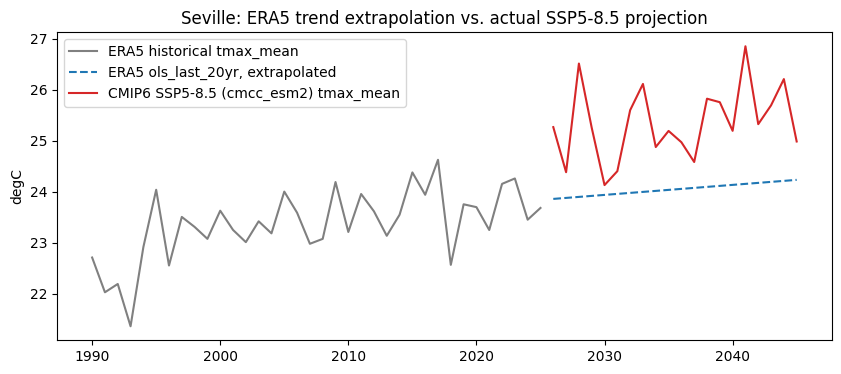

Mean gap 2026-2045: +1.31 degC (positive = SSP5-8.5 projection warmer than the historical-trend extrapolation)


,cmip6_tmax_mean,era5_ols_last20yr_extrapolated,gap_c
year,,,
2026,25.267205,23.858188,1.409017
2027,24.382082,23.877849,0.504233
2028,26.514646,23.897510,2.617136
2029,25.254938,23.917171,1.337767
2030,24.129468,23.936831,0.192636
2031,24.402331,23.956492,0.445839
2032,25.599811,23.976153,1.623658
2033,26.114627,23.995814,2.118813
2034,24.876167,24.015475,0.860693


In [12]:
era5_annual = pd.read_csv(ERA5_ANNUAL_CSV, index_col="year")
last20 = era5_annual.loc[2006:2025, "tmax_mean"]
lr = stats.linregress(last20.index.values.astype(float), last20.values.astype(float))

proj_years = annual_summary.index.values.astype(float)
era5_extrapolated = lr.intercept + lr.slope * proj_years

comparison = pd.DataFrame({
    "cmip6_tmax_mean": annual_summary["tmax_mean"],
    "era5_ols_last20yr_extrapolated": era5_extrapolated,
}, index=annual_summary.index)
comparison["gap_c"] = comparison["cmip6_tmax_mean"] - comparison["era5_ols_last20yr_extrapolated"]
comparison.to_csv(OUT / "seville_projection_vs_era5_extrapolation.csv")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(era5_annual.index, era5_annual["tmax_mean"], label="ERA5 historical tmax_mean", color="gray")
ax.plot(proj_years, era5_extrapolated, "--", label="ERA5 ols_last_20yr, extrapolated", color="tab:blue")
ax.plot(proj_years, annual_summary["tmax_mean"], label="CMIP6 SSP5-8.5 (cmcc_esm2) tmax_mean", color="tab:red")
ax.set_ylabel("degC")
ax.set_title("Seville: ERA5 trend extrapolation vs. actual SSP5-8.5 projection")
ax.legend()
plt.show()

print(f"Mean gap 2026-2045: {comparison['gap_c'].mean():+.2f} degC "
      f"(positive = SSP5-8.5 projection warmer than the historical-trend extrapolation)")
comparison

## 12. What could not be carried over from the ERA5 pipeline

- **Fire Weather Index / `longest_high_run` (Seville's third `Climate_Indicators_Modeling.ipynb`
  indicator) has no path forward here at all.** It's not computed from a formula over ERA5
  variables in this codebase -- it's a directly-downloaded, precomputed product from a completely
  separate Copernicus data source (`cems-fire-historical-v1`, the CEMS Early Warning Data Store,
  pulled by `fetch_seville_fire.py`), requiring local-noon temperature/RH/wind/24h-precip inputs
  this pipeline never assembles. `documentation/projection_data_pull_plan.md` already confirmed
  neither `sis-ecde-climate-indicators` nor `sis-extreme-indices-cmip6` offers an SSP5-8.5
  fire-danger product. This indicator is out of scope for the projection period; the eventual
  `min_spi3`/`tmax_mean`/`longest_high_run` compound comparison in `Climate_Indicators_Modeling.ipynb`
  can only be completed for the first two.
- **Wind rose / prevailing-direction analysis is dropped.** The CMIP6 pull only has scalar
  `sfcWind` (speed), not `u10`/`v10` components -- `wind_direction()` has nothing to compute from.
- **Diurnal cycle and the "how much of the true daily range does sampling capture" comparison don't
  apply.** CMIP6 is daily-native with no sub-daily samples to summarize; there's no intra-day
  variation left to describe.
- **`heat_index_c` (Section 5) is a redefinition, not a like-for-like port** -- computed once per
  day from daily-mean T/RH rather than as the max of six intra-day samples. Named differently from
  the historical `heat_index_max_c` for that reason; don't join the two columns as if comparable.
- **SPI-3 / `min_spi3` for the projection period is deferred, not attempted here** -- consistent
  with `seville_era5_eda.ipynb` itself, which also defers SPI to a separate notebook
  (`Calculating_SPI_for_Seville.ipynb`) rather than computing it inline. `precip_mm_day` summed to
  monthly is exactly what a projection-period SPI-3 notebook would need as input (scored against
  the existing ERA5 1990-2020 gamma fit, never refit -- same principle as Section 6's temperature
  threshold); building that notebook is the natural next step, not part of this one.

## 13. Summary

Outputs written to `eda_results/eda_outputs_seville_projection/`:

- `seville_projection_daily.csv` -- daily frame, grid-averaged, unit-converted
- `seville_projection_heatwave_events.csv` -- heatwave events detected against the fixed ERA5
  1990-2020 P90-by-day-of-year threshold
- `seville_projection_annual_summary.csv` -- annual indicator table, same shape as the ERA5
  `annual_summary.csv`
- `seville_projection_trends.csv` -- within-projection-period trend table (2026-2045)
- `seville_projection_vs_era5_extrapolation.csv` -- `tmax_mean` gap between the SSP5-8.5 projection
  and the ERA5 historical-trend extrapolation

Next steps: build the equivalent Larissa notebook (same structure, `tmin_mean`/`precip_scaled`/
`max_week_precip_mm` as the relevant indicators rather than Seville's heat/drought/fire set); a
projection-period SPI-3 notebook per Section 12; and, once both exist, extend
`Climate_Indicators_Modeling.ipynb`'s Section 10 from prose into an actual comparison using these
exported CSVs.